In [1]:
import keras
from keras.models import Sequential
from keras.layers import Conv2D,Flatten,Dense,MaxPooling2D,Dropout
from keras.preprocessing.image import ImageDataGenerator
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

In [2]:
import io
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
import cv2
from sklearn.utils import shuffle
import tensorflow as tf

In [3]:
X_train = []
Y_train = []

image_size = 150

labels = ['Alluvial soil','Black Soil','Clay soil','Red soil']

for i in labels:
    folderPath = os.path.join('../../dataset/train',i)

    for j in os.listdir(folderPath):
        img = cv2.imread(os.path.join(folderPath,j))
        img = cv2.resize(img,(image_size,image_size))
        X_train.append(img)
        Y_train.append(i)
        
for i in labels:
    folderPath = os.path.join('../../dataset/test',i)
    for j in os.listdir(folderPath):
        img = cv2.imread(os.path.join(folderPath,j))
        img = cv2.resize(img,(image_size,image_size))
        X_train.append(img)
        Y_train.append(i)

X_train = np.array(X_train)
Y_train = np.array(Y_train)

In [4]:
Y_train

array(['Alluvial soil', 'Alluvial soil', 'Alluvial soil', ..., 'Red soil',
       'Red soil', 'Red soil'], dtype='<U13')

In [5]:
X_train,Y_train = shuffle(X_train,Y_train,random_state=101)
X_train.shape

(1555, 150, 150, 3)

In [6]:
len(X_train)

1555

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X_train,Y_train,test_size=0.1,random_state=101)

In [8]:
print(y_train)

['Clay soil' 'Alluvial soil' 'Red soil' ... 'Alluvial soil' 'Black Soil'
 'Red soil']


In [9]:
y_train_new = []
for i in y_train:
    y_train_new.append(labels.index(i))
y_train=y_train_new
y_train = tf.keras.utils.to_categorical(y_train,num_classes=4)

y_test_new = []
for i in y_test:
    y_test_new.append(labels.index(i))
y_test=y_test_new
y_test = tf.keras.utils.to_categorical(y_test,num_classes=4)

In [10]:
y_train

array([[0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       ...,
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.]], dtype=float32)

In [11]:
y_test

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],


In [12]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=5, 
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    brightness_range=[0.8, 1.2], 
    validation_split=0.2
)

validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_ds= train_datagen.flow(
        X_train, y_train, batch_size=32,
)

validation_ds = validation_datagen.flow(
        X_test, y_test, batch_size=32,)

In [14]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

base_model = EfficientNetB0(
    
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

In [20]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(), 
    Dropout(0.3),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

In [21]:
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional  (None, 7, 7, 1280)        4049571   
 )                                                               
                                                                 
 global_average_pooling2d_4  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dropout_8 (Dropout)         (None, 1280)              0         
                                                                 
 dense_8 (Dense)             (None, 512)               655872    
                                                                 
 dropout_9 (Dropout)         (None, 512)               0         
                                                                 
 dense_9 (Dense)             (None, 4)                

In [22]:
base_model.trainable = True
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
history = model.fit(
    train_ds,
    epochs = 100,
    validation_data = validation_ds,
)

Epoch 1/100


44/44 [==============================] - 58s 675ms/step - loss: 1.4746 - accuracy: 0.2974 - val_loss: 1.3766 - val_accuracy: 0.3462
Epoch 2/100
44/44 [==============================] - 26s 590ms/step - loss: 1.3255 - accuracy: 0.3981 - val_loss: 1.4071 - val_accuracy: 0.2308
Epoch 3/100
44/44 [==============================] - 27s 612ms/step - loss: 1.1244 - accuracy: 0.5497 - val_loss: 1.4332 - val_accuracy: 0.0769
Epoch 4/100
44/44 [==============================] - 28s 636ms/step - loss: 1.0423 - accuracy: 0.5926 - val_loss: 1.4261 - val_accuracy: 0.0962
Epoch 5/100
44/44 [==============================] - 26s 593ms/step - loss: 0.9064 - accuracy: 0.6905 - val_loss: 1.4303 - val_accuracy: 0.1731
Epoch 6/100
44/44 [==============================] - 26s 579ms/step - loss: 0.8278 - accuracy: 0.7177 - val_loss: 1.3702 - val_accuracy: 0.2372
Epoch 7/100
44/44 [==============================] - 26s 580ms/step - loss: 0.7419 - accuracy: 0.7634 - val_loss: 1.3621 - val_accurac

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

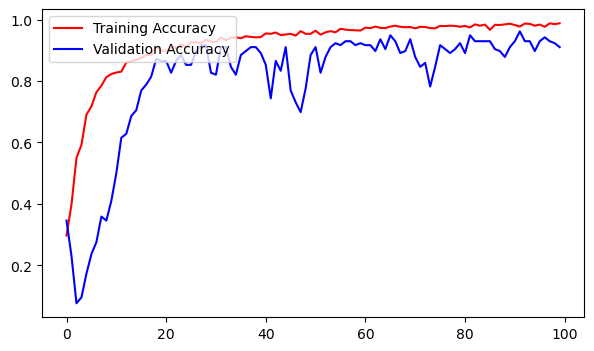

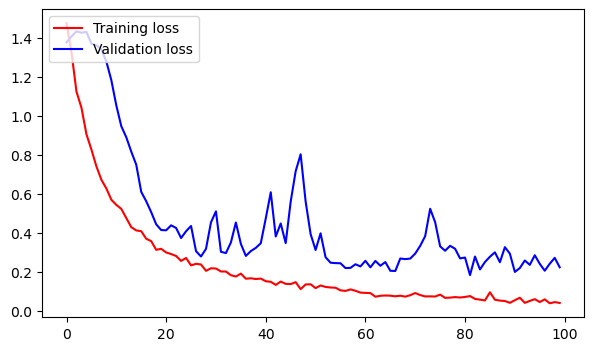

In [25]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(len(acc))
fig = plt.figure(figsize=(7,4))
plt.plot(epochs,acc,'r',label="Training Accuracy")
plt.plot(epochs,val_acc,'b',label="Validation Accuracy")
plt.legend(loc='upper left')
plt.savefig('../../result/train_phase_test.png', dpi=300, bbox_inches='tight')
plt.show()

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(loss))
fig = plt.figure(figsize=(7,4))
plt.plot(epochs,loss,'r',label="Training loss")
plt.plot(epochs,val_loss,'b',label="Validation loss")
plt.legend(loc='upper left')
plt.savefig('../../result/loss_phase_test.png', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
model.save('../../model/clf_model_phase_test.h5')

c:\Users\ferdy\development\anaconda\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
